# GSE2034 유전자 발현 기반 분류·회귀 모델

[GEO GSE2034](https://www.ncbi.nlm.nih.gov/geo/query/acc.cgi?acc=GSE2034) — Wang et al., *Lancet* 2005  
림프절 음성 원발 유방암 286명의 Affymetrix HG-U133A 발현으로:

- **분류**: 원격전이(재발) 여부 예측
- **회귀**: 재발 환자의 원격전이까지 기간(개월) 예측
- **보조 분류**: ER+/ER− 상태 예측

> 교육·연구용 데모이며 임상 진단용이 아닙니다.


## 1. 환경 설정

In [1]:
from __future__ import annotations

import gzip
import io
import json
import warnings
from pathlib import Path
from urllib.request import urlretrieve

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.ensemble import GradientBoostingClassifier, GradientBoostingRegressor
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.feature_selection import SelectKBest, f_classif, f_regression
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore", category=FutureWarning)
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.unicode_minus"] = False

RANDOM_STATE = 42
N_FEATURES = 500  # SelectKBest로 남길 프로브 수

ROOT = Path.cwd()
DATA_DIR = ROOT / "data"
OUT_DIR = ROOT / "outputs"
DATA_DIR.mkdir(exist_ok=True)
OUT_DIR.mkdir(exist_ok=True)

MATRIX_URL = (
    "https://ftp.ncbi.nlm.nih.gov/geo/series/GSE2nnn/GSE2034/matrix/"
    "GSE2034_series_matrix.txt.gz"
)
SOFT_URL = (
    "https://ftp.ncbi.nlm.nih.gov/geo/series/GSE2nnn/GSE2034/soft/"
    "GSE2034_family.soft.gz"
)

MATRIX_PATH = DATA_DIR / "GSE2034_series_matrix.txt.gz"
SOFT_PATH = DATA_DIR / "GSE2034_family.soft.gz"
CLINICAL_CACHE = DATA_DIR / "GSE2034_clinical.csv"
EXPR_CACHE = DATA_DIR / "GSE2034_expression.parquet"

print("ROOT:", ROOT)
print("DATA:", DATA_DIR)
print("OUT :", OUT_DIR)

ROOT: c:\MyCursorLab\03_바이오 예측 및 분석 리포트 자동화\01_유전자 발현 기반 분류·회귀 모델 생성
DATA: c:\MyCursorLab\03_바이오 예측 및 분석 리포트 자동화\01_유전자 발현 기반 분류·회귀 모델 생성\data
OUT : c:\MyCursorLab\03_바이오 예측 및 분석 리포트 자동화\01_유전자 발현 기반 분류·회귀 모델 생성\outputs


## 2. GEO 데이터 다운로드

- **Series Matrix**: 정규화 발현 행렬
- **SOFT family**: Patient clinical parameters (재발, 추적기간, ER 등)

In [2]:
def download_if_needed(url: str, dest: Path) -> Path:
    if dest.exists() and dest.stat().st_size > 0:
        print(f"[캐시] {dest.name} ({dest.stat().st_size / 1e6:.1f} MB)")
        return dest
    print(f"[다운로드] {url}")
    urlretrieve(url, dest)
    print(f"[완료] {dest.name} ({dest.stat().st_size / 1e6:.1f} MB)")
    return dest


download_if_needed(MATRIX_URL, MATRIX_PATH)
download_if_needed(SOFT_URL, SOFT_PATH)

[캐시] GSE2034_series_matrix.txt.gz (14.3 MB)
[캐시] GSE2034_family.soft.gz (65.3 MB)


WindowsPath('c:/MyCursorLab/03_바이오 예측 및 분석 리포트 자동화/01_유전자 발현 기반 분류·회귀 모델 생성/data/GSE2034_family.soft.gz')

## 3. 발현 행렬 · 임상 정보 파싱

In [3]:
def parse_series_matrix(path: Path) -> tuple[pd.DataFrame, pd.Series]:
    """발현 행렬(samples × probes)과 bone relapse 특성을 반환."""
    bone = None
    table_lines: list[str] = []
    in_table = False

    with gzip.open(path, "rt", encoding="utf-8", errors="replace") as f:
        for line in f:
            line = line.rstrip("\n")
            if line.startswith("!Sample_characteristics_ch1"):
                parts = [p.strip().strip('"') for p in line.split("\t")[1:]]
                bone = pd.Series(parts, dtype="object")
            elif line.startswith("!series_matrix_table_begin"):
                in_table = True
                continue
            elif line.startswith("!series_matrix_table_end"):
                break
            elif in_table:
                table_lines.append(line)

    raw = pd.read_csv(io.StringIO("\n".join(table_lines)), sep="\t")
    raw = raw.rename(columns={raw.columns[0]: "ID_REF"}).set_index("ID_REF")
    raw.columns = [c.strip().strip('"') for c in raw.columns]
    expr = raw.T.astype(float)
    expr.index.name = "gsm"

    if bone is None:
        raise RuntimeError("Sample_characteristics_ch1을 찾지 못했습니다.")
    bone.index = expr.index
    bone_relapse = (
        bone.str.extract(r":\s*(\d+)", expand=False).astype(float).astype("Int64")
    )
    bone_relapse.name = "bone_relapse"
    return expr, bone_relapse


def parse_clinical_from_soft(path: Path) -> pd.DataFrame:
    """SOFT family에서 Patient clinical parameters 테이블 추출."""
    rows: list[str] = []
    capture = False
    header = None

    with gzip.open(path, "rt", encoding="utf-8", errors="replace") as f:
        for line in f:
            line = line.rstrip("\n")
            if line.startswith("!series_table_begin") and "Patient clinical parameters" in line:
                capture = True
                continue
            if capture and line.startswith("!series_table_end"):
                break
            if capture:
                if header is None:
                    header = line
                else:
                    rows.append(line)

    if not header or not rows:
        raise RuntimeError("SOFT에서 임상 테이블을 찾지 못했습니다.")

    clin = pd.read_csv(io.StringIO("\n".join([header] + rows)), sep="\t")
    clin = clin.rename(
        columns={
            "GEO asscession number": "gsm",
            "GEO accession number": "gsm",
            "lymph node status": "lymph_node_status",
            "time to relapse or last follow-up (months)": "months",
            "relapse (1=True)": "relapse",
            "ER Status": "er_status",
            "Brain relapses (1=yes, 0=no)": "brain_relapse",
        }
    )
    clin["gsm"] = clin["gsm"].astype(str).str.strip()
    clin["relapse"] = clin["relapse"].astype(int)
    clin["months"] = clin["months"].astype(float)
    clin["brain_relapse"] = clin["brain_relapse"].astype(int)
    clin["er_positive"] = (clin["er_status"].str.upper() == "ER+").astype(int)
    return clin.set_index("gsm")


if EXPR_CACHE.exists() and CLINICAL_CACHE.exists():
    print("[캐시] 전처리된 발현/임상 로드")
    expr = pd.read_parquet(EXPR_CACHE)
    clin = pd.read_csv(CLINICAL_CACHE, index_col="gsm")
else:
    expr, bone_relapse = parse_series_matrix(MATRIX_PATH)
    clin = parse_clinical_from_soft(SOFT_PATH)
    # 행 순서가 다를 수 있으므로 GSM으로 조인
    common = expr.index.intersection(clin.index)
    expr = expr.loc[common]
    clin = clin.loc[common]
    clin["bone_relapse"] = bone_relapse.loc[common].astype(int)
    expr.to_parquet(EXPR_CACHE)
    clin.to_csv(CLINICAL_CACHE)
    print(f"캐시 저장: {EXPR_CACHE.name}, {CLINICAL_CACHE.name}")

print("발현:", expr.shape, "(samples × probes)")
print("임상:", clin.shape)
display(clin.head())
print("재발 분포:\n", clin["relapse"].value_counts().to_string())
print("ER 분포:\n", clin["er_status"].value_counts().to_string())

[캐시] 전처리된 발현/임상 로드
발현: (286, 22283) (samples × probes)
임상: (286, 8)


,PID,lymph_node_status,months,relapse,er_status,brain_relapse,er_positive,bone_relapse
gsm,,,,,,,,
GSM36777,277,negative,79.0,0,ER+,0,1,0
GSM36778,278,negative,50.0,1,ER+,0,1,0
GSM36779,798,negative,132.0,0,ER+,0,1,0
GSM36780,846,negative,84.0,0,ER-,0,0,0
GSM36781,765,negative,147.0,0,ER+,0,1,0


재발 분포:
 relapse
0    179
1    107
ER 분포:
 er_status
ER+    209
ER-     77


## 4. 전처리 (log2 · 분산 필터 · train/test 분할)

분산 필터 후 프로브 수: 11,142
Train: (214, 11142) | Test: (72, 11142)
Train 재발 비율: 0.374
Test  재발 비율: 0.375


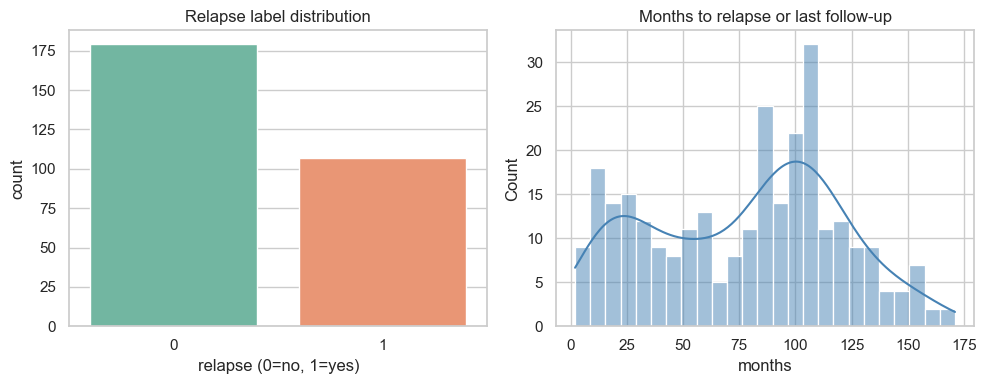

In [4]:
# MAS5 스케일 강도 → log2 (0 방지)
X_all = np.log2(expr.clip(lower=1.0))

# 저분산 프로브 제거 (상위 50% 분산 유지)
probe_var = X_all.var(axis=0)
keep_probes = probe_var[probe_var >= probe_var.median()].index
X_all = X_all[keep_probes]
print(f"분산 필터 후 프로브 수: {X_all.shape[1]:,}")

y_cls = clin["relapse"].astype(int)
y_reg = clin["months"].astype(float)

X_train, X_test, y_cls_train, y_cls_test, y_reg_train, y_reg_test = train_test_split(
    X_all,
    y_cls,
    y_reg,
    test_size=0.25,
    random_state=RANDOM_STATE,
    stratify=y_cls,
)

print("Train:", X_train.shape, "| Test:", X_test.shape)
print(f"Train 재발 비율: {y_cls_train.mean():.3f}")
print(f"Test  재발 비율: {y_cls_test.mean():.3f}")

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
sns.countplot(x=y_cls, ax=axes[0], palette="Set2")
axes[0].set_title("Relapse label distribution")
axes[0].set_xlabel("relapse (0=no, 1=yes)")
sns.histplot(y_reg, bins=25, kde=True, ax=axes[1], color="steelblue")
axes[1].set_title("Months to relapse or last follow-up")
axes[1].set_xlabel("months")
plt.tight_layout()
plt.savefig(OUT_DIR / "01_label_distributions.png", dpi=140, bbox_inches="tight")
plt.show()


## 5. 분류 모델 — 원격전이(재발) 예측

In [5]:
cls_models = {
    "LogisticRegression": Pipeline(
        [
            ("scaler", StandardScaler()),
            ("select", SelectKBest(f_classif, k=N_FEATURES)),
            (
                "model",
                LogisticRegression(
                    max_iter=2000,
                    class_weight="balanced",
                    random_state=RANDOM_STATE,
                ),
            ),
        ]
    ),
    "RandomForest": Pipeline(
        [
            ("select", SelectKBest(f_classif, k=N_FEATURES)),
            (
                "model",
                RandomForestClassifier(
                    n_estimators=300,
                    max_depth=None,
                    min_samples_leaf=2,
                    class_weight="balanced_subsample",
                    random_state=RANDOM_STATE,
                    n_jobs=-1,
                ),
            ),
        ]
    ),
    "GradientBoosting": Pipeline(
        [
            ("select", SelectKBest(f_classif, k=N_FEATURES)),
            (
                "model",
                GradientBoostingClassifier(
                    n_estimators=200,
                    learning_rate=0.05,
                    max_depth=3,
                    random_state=RANDOM_STATE,
                ),
            ),
        ]
    ),
}

cls_rows = []
cls_fitted = {}

for name, pipe in cls_models.items():
    pipe.fit(X_train, y_cls_train)
    pred = pipe.predict(X_test)
    proba = pipe.predict_proba(X_test)[:, 1]
    acc = accuracy_score(y_cls_test, pred)
    auc = roc_auc_score(y_cls_test, proba)
    cls_rows.append({"model": name, "accuracy": acc, "roc_auc": auc})
    cls_fitted[name] = pipe
    print(f"\n=== {name} ===")
    print(f"Accuracy={acc:.3f} | ROC-AUC={auc:.3f}")
    print(classification_report(y_cls_test, pred, digits=3))

cls_metrics = pd.DataFrame(cls_rows).sort_values("roc_auc", ascending=False)
display(cls_metrics)
cls_metrics.to_csv(OUT_DIR / "classification_metrics.csv", index=False)

best_cls_name = cls_metrics.iloc[0]["model"]
best_cls = cls_fitted[best_cls_name]
print("Best classifier:", best_cls_name)


=== LogisticRegression ===
Accuracy=0.694 | ROC-AUC=0.705
              precision    recall  f1-score   support

           0      0.695     0.911     0.788        45
           1      0.692     0.333     0.450        27

    accuracy                          0.694        72
   macro avg      0.694     0.622     0.619        72
weighted avg      0.694     0.694     0.662        72


=== RandomForest ===
Accuracy=0.583 | ROC-AUC=0.637
              precision    recall  f1-score   support

           0      0.627     0.822     0.712        45
           1      0.385     0.185     0.250        27

    accuracy                          0.583        72
   macro avg      0.506     0.504     0.481        72
weighted avg      0.536     0.583     0.538        72


=== GradientBoosting ===
Accuracy=0.653 | ROC-AUC=0.613
              precision    recall  f1-score   support

           0      0.679     0.844     0.752        45
           1      0.562     0.333     0.419        27

    accuracy 

,model,accuracy,roc_auc
0,LogisticRegression,0.694444,0.705350
1,RandomForest,0.583333,0.637037
2,GradientBoosting,0.652778,0.613169


Best classifier: LogisticRegression


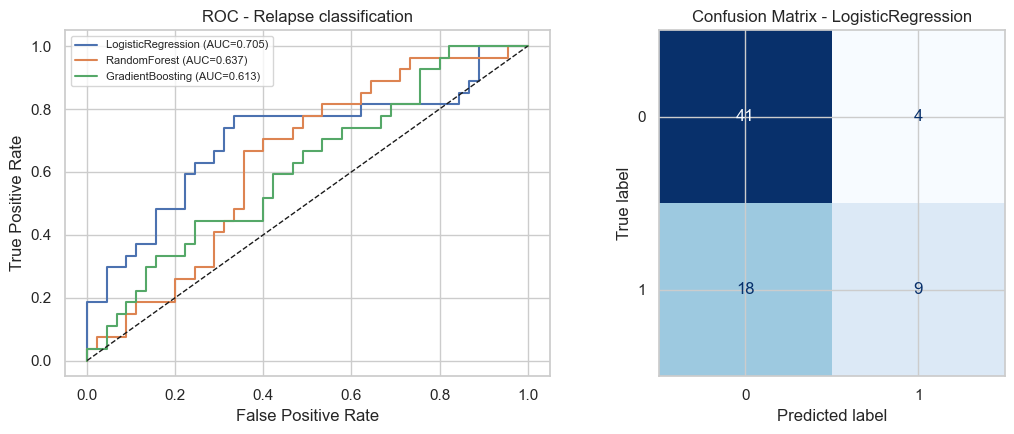

['c:\\MyCursorLab\\03_바이오 예측 및 분석 리포트 자동화\\01_유전자 발현 기반 분류·회귀 모델 생성\\outputs\\best_classifier_LogisticRegression.joblib']

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

# ROC curves
for name, pipe in cls_fitted.items():
    proba = pipe.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_cls_test, proba)
    auc = roc_auc_score(y_cls_test, proba)
    axes[0].plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})")
axes[0].plot([0, 1], [0, 1], "k--", lw=1)
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("ROC - Relapse classification")
axes[0].legend(fontsize=8)

# Confusion matrix (best)
pred_best = best_cls.predict(X_test)
ConfusionMatrixDisplay.from_predictions(
    y_cls_test, pred_best, ax=axes[1], cmap="Blues", colorbar=False
)
axes[1].set_title(f"Confusion Matrix - {best_cls_name}")
plt.tight_layout()
plt.savefig(OUT_DIR / "02_classification_roc_cm.png", dpi=140, bbox_inches="tight")
plt.show()

joblib.dump(best_cls, OUT_DIR / f"best_classifier_{best_cls_name}.joblib")


### 분류 — 상위 기여 프로브

,probe,abs_coef
0,206984_s_at,0.474916
1,220469_at,0.419421
2,206644_at,0.368910
3,215316_at,0.365150
4,207190_at,0.360945
5,217431_x_at,0.349258
6,215289_at,0.327537
7,221525_at,0.320375
8,204698_at,0.318787
9,213443_at,0.314065


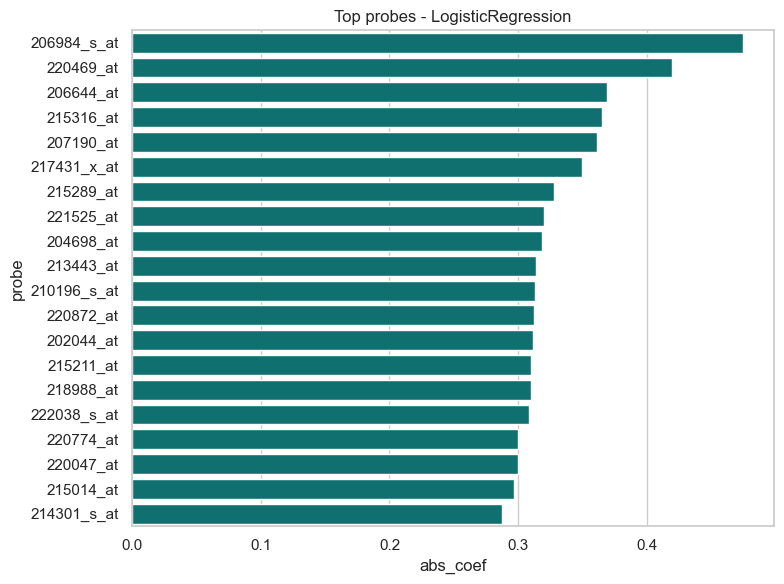

In [7]:
def selected_feature_names(pipe: Pipeline, original_cols) -> np.ndarray:
    mask = pipe.named_steps["select"].get_support()
    return np.asarray(original_cols)[mask]


def top_classifier_features(pipe: Pipeline, original_cols, top_n: int = 20) -> pd.DataFrame:
    names = selected_feature_names(pipe, original_cols)
    model = pipe.named_steps["model"]
    if hasattr(model, "feature_importances_"):
        score = model.feature_importances_
        label = "importance"
    elif hasattr(model, "coef_"):
        score = np.abs(model.coef_).ravel()
        label = "abs_coef"
    else:
        raise ValueError("모델에서 중요도를 추출할 수 없습니다.")
    out = (
        pd.DataFrame({"probe": names, label: score})
        .sort_values(label, ascending=False)
        .head(top_n)
        .reset_index(drop=True)
    )
    return out


top_cls = top_classifier_features(best_cls, X_train.columns, top_n=20)
display(top_cls)
top_cls.to_csv(OUT_DIR / "top_probes_classification.csv", index=False)

score_col = [c for c in top_cls.columns if c != "probe"][0]
fig, ax = plt.subplots(figsize=(8, 6))
sns.barplot(data=top_cls, y="probe", x=score_col, ax=ax, color="teal")
ax.set_title(f"Top probes - {best_cls_name}")
plt.tight_layout()
plt.savefig(OUT_DIR / "03_top_probes_classification.png", dpi=140, bbox_inches="tight")
plt.show()


## 6. 회귀 모델 - 원격전이까지 개월 수 예측

검열된 추적기간을 섞지 않도록 **재발(relapse=1) 환자만** 사용해 time-to-distant-metastasis(개월)를 회귀합니다.


In [8]:
# 재발(event) 환자만: 원격전이까지 실제 소요 개월 수 회귀
relapse_mask = clin["relapse"] == 1
X_rel = X_all.loc[relapse_mask]
y_time = clin.loc[relapse_mask, "months"].astype(float)
print(f"재발 환자 수(회귀용): {len(y_time)}")

X_tr_r, X_te_r, y_tr_r, y_te_r = train_test_split(
    X_rel, y_time, test_size=0.25, random_state=RANDOM_STATE
)

reg_models = {
    "Ridge": Pipeline(
        [
            ("scaler", StandardScaler()),
            ("select", SelectKBest(f_regression, k=min(N_FEATURES, X_tr_r.shape[1]))),
            ("model", Ridge(alpha=10.0)),
        ]
    ),
    "RandomForest": Pipeline(
        [
            ("select", SelectKBest(f_regression, k=min(N_FEATURES, X_tr_r.shape[1]))),
            (
                "model",
                RandomForestRegressor(
                    n_estimators=300,
                    min_samples_leaf=2,
                    random_state=RANDOM_STATE,
                    n_jobs=-1,
                ),
            ),
        ]
    ),
    "GradientBoosting": Pipeline(
        [
            ("select", SelectKBest(f_regression, k=min(N_FEATURES, X_tr_r.shape[1]))),
            (
                "model",
                GradientBoostingRegressor(
                    n_estimators=200,
                    learning_rate=0.05,
                    max_depth=3,
                    random_state=RANDOM_STATE,
                ),
            ),
        ]
    ),
}

reg_rows = []
reg_fitted = {}
reg_preds = {}

for name, pipe in reg_models.items():
    pipe.fit(X_tr_r, y_tr_r)
    pred = pipe.predict(X_te_r)
    mae = mean_absolute_error(y_te_r, pred)
    rmse = mean_squared_error(y_te_r, pred) ** 0.5
    r2 = r2_score(y_te_r, pred)
    reg_rows.append({"model": name, "MAE": mae, "RMSE": rmse, "R2": r2})
    reg_fitted[name] = pipe
    reg_preds[name] = pred
    print(f"{name:18s}  MAE={mae:6.2f}  RMSE={rmse:6.2f}  R2={r2:6.3f}")

reg_metrics = pd.DataFrame(reg_rows).sort_values("MAE")
display(reg_metrics)
reg_metrics.to_csv(OUT_DIR / "regression_metrics.csv", index=False)

best_reg_name = reg_metrics.iloc[0]["model"]
best_reg = reg_fitted[best_reg_name]
print("Best regressor:", best_reg_name)


재발 환자 수(회귀용): 107
Ridge               MAE= 16.14  RMSE= 19.39  R2= 0.160
RandomForest        MAE= 16.12  RMSE= 19.01  R2= 0.193
GradientBoosting    MAE= 16.31  RMSE= 20.76  R2= 0.038


,model,MAE,RMSE,R2
1,RandomForest,16.119128,19.009303,0.193397
0,Ridge,16.139868,19.394235,0.160400
2,GradientBoosting,16.311325,20.764255,0.037590


Best regressor: RandomForest


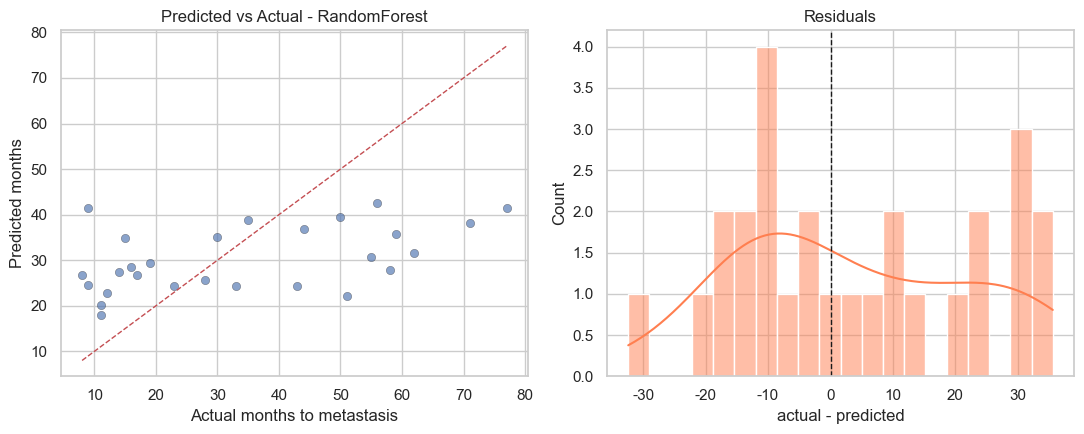

['c:\\MyCursorLab\\03_바이오 예측 및 분석 리포트 자동화\\01_유전자 발현 기반 분류·회귀 모델 생성\\outputs\\best_regressor_RandomForest.joblib']

In [9]:
pred_reg = reg_preds[best_reg_name]
resid = y_te_r.to_numpy() - pred_reg

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
axes[0].scatter(y_te_r, pred_reg, alpha=0.65, edgecolor="k", linewidth=0.3)
lims = [
    min(y_te_r.min(), pred_reg.min()),
    max(y_te_r.max(), pred_reg.max()),
]
axes[0].plot(lims, lims, "r--", lw=1)
axes[0].set_xlabel("Actual months to metastasis")
axes[0].set_ylabel("Predicted months")
axes[0].set_title(f"Predicted vs Actual - {best_reg_name}")

sns.histplot(resid, bins=20, kde=True, ax=axes[1], color="coral")
axes[1].axvline(0, color="k", ls="--", lw=1)
axes[1].set_title("Residuals")
axes[1].set_xlabel("actual - predicted")
plt.tight_layout()
plt.savefig(OUT_DIR / "04_regression_pred_resid.png", dpi=140, bbox_inches="tight")
plt.show()

joblib.dump(best_reg, OUT_DIR / f"best_regressor_{best_reg_name}.joblib")


,probe,importance
0,214095_at,0.051324
1,213464_at,0.041518
2,222184_at,0.040018
3,204886_at,0.025827
4,207496_at,0.025695
5,202134_s_at,0.023155
6,217628_at,0.022350
7,219440_at,0.021048
8,212141_at,0.020216
9,217074_at,0.018028


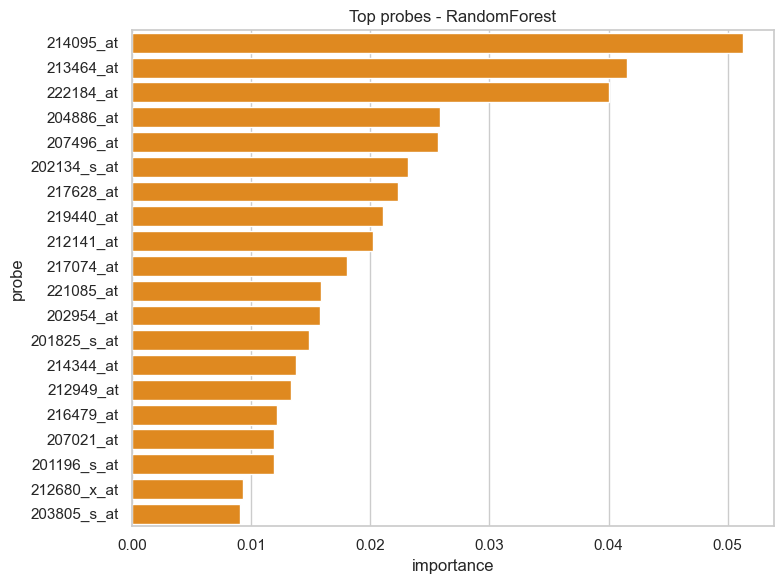

In [10]:
def top_regressor_features(pipe: Pipeline, original_cols, top_n: int = 20) -> pd.DataFrame:
    names = selected_feature_names(pipe, original_cols)
    model = pipe.named_steps["model"]
    if hasattr(model, "feature_importances_"):
        score = model.feature_importances_
        label = "importance"
    elif hasattr(model, "coef_"):
        score = np.abs(model.coef_).ravel()
        label = "abs_coef"
    else:
        raise ValueError("모델에서 중요도를 추출할 수 없습니다.")
    return (
        pd.DataFrame({"probe": names, label: score})
        .sort_values(label, ascending=False)
        .head(top_n)
        .reset_index(drop=True)
    )


top_reg = top_regressor_features(best_reg, X_tr_r.columns, top_n=20)
display(top_reg)
top_reg.to_csv(OUT_DIR / "top_probes_regression.csv", index=False)

score_col = [c for c in top_reg.columns if c != "probe"][0]
fig, ax = plt.subplots(figsize=(8, 6))
sns.barplot(data=top_reg, y="probe", x=score_col, ax=ax, color="darkorange")
ax.set_title(f"Top probes - {best_reg_name}")
plt.tight_layout()
plt.savefig(OUT_DIR / "05_top_probes_regression.png", dpi=140, bbox_inches="tight")
plt.show()


## 7. (선택) ER 상태 보조 분류

동일 발현 행렬로 ER+/ER− 이진 분류를 추가로 학습합니다.

In [11]:
y_er = clin["er_positive"].astype(int)
X_tr_er, X_te_er, y_tr_er, y_te_er = train_test_split(
    X_all, y_er, test_size=0.25, random_state=RANDOM_STATE, stratify=y_er
)

er_pipe = Pipeline(
    [
        ("scaler", StandardScaler()),
        ("select", SelectKBest(f_classif, k=N_FEATURES)),
        (
            "model",
            LogisticRegression(
                max_iter=2000, class_weight="balanced", random_state=RANDOM_STATE
            ),
        ),
    ]
)
er_pipe.fit(X_tr_er, y_tr_er)
er_proba = er_pipe.predict_proba(X_te_er)[:, 1]
er_pred = er_pipe.predict(X_te_er)
print("ER Accuracy:", accuracy_score(y_te_er, er_pred))
print("ER ROC-AUC :", roc_auc_score(y_te_er, er_proba))
print(classification_report(y_te_er, er_pred, target_names=["ER-", "ER+"], digits=3))

joblib.dump(er_pipe, OUT_DIR / "er_classifier_LogisticRegression.joblib")

ER Accuracy: 0.8888888888888888
ER ROC-AUC : 0.9374379344587885
              precision    recall  f1-score   support

         ER-      0.789     0.789     0.789        19
         ER+      0.925     0.925     0.925        53

    accuracy                          0.889        72
   macro avg      0.857     0.857     0.857        72
weighted avg      0.889     0.889     0.889        72



['c:\\MyCursorLab\\03_바이오 예측 및 분석 리포트 자동화\\01_유전자 발현 기반 분류·회귀 모델 생성\\outputs\\er_classifier_LogisticRegression.joblib']

## 8. 결과 요약 저장

In [12]:
summary = {
    "dataset": "GSE2034",
    "n_samples": int(X_all.shape[0]),
    "n_probes_after_var_filter": int(X_all.shape[1]),
    "n_features_selected": N_FEATURES,
    "best_classifier": best_cls_name,
    "best_classifier_metrics": cls_metrics.iloc[0].to_dict(),
    "best_regressor": best_reg_name,
    "best_regressor_metrics": reg_metrics.iloc[0].to_dict(),
    "er_accuracy": float(accuracy_score(y_te_er, er_pred)),
    "er_roc_auc": float(roc_auc_score(y_te_er, er_proba)),
    "note": "Research/education demo only - not for clinical use.",
}

with open(OUT_DIR / "run_summary.json", "w", encoding="utf-8") as f:
    json.dump(summary, f, ensure_ascii=False, indent=2)

print(json.dumps(summary, ensure_ascii=False, indent=2))
print(f"\n산출물 디렉터리: {OUT_DIR.resolve()}")
for p in sorted(OUT_DIR.glob("*")):
    print(" -", p.name)


{
  "dataset": "GSE2034",
  "n_samples": 286,
  "n_probes_after_var_filter": 11142,
  "n_features_selected": 500,
  "best_classifier": "LogisticRegression",
  "best_classifier_metrics": {
    "model": "LogisticRegression",
    "accuracy": 0.6944444444444444,
    "roc_auc": 0.705349794238683
  },
  "best_regressor": "RandomForest",
  "best_regressor_metrics": {
    "model": "RandomForest",
    "MAE": 16.11912798175761,
    "RMSE": 19.009303258784477,
    "R2": 0.19339724065105712
  },
  "er_accuracy": 0.8888888888888888,
  "er_roc_auc": 0.9374379344587885,
  "note": "Research/education demo only - not for clinical use."
}

산출물 디렉터리: C:\MyCursorLab\03_바이오 예측 및 분석 리포트 자동화\01_유전자 발현 기반 분류·회귀 모델 생성\outputs
 - 01_label_distributions.png
 - 02_classification_roc_cm.png
 - 03_top_probes_classification.png
 - 04_regression_pred_resid.png
 - 05_top_probes_regression.png
 - best_classifier_LogisticRegression.joblib
 - best_regressor_GradientBoosting.joblib
 - best_regressor_RandomForest.joblib
 -

## 참고

- Wang Y et al. Gene-expression profiles to predict distant metastasis of lymph-node-negative primary breast cancer. *Lancet*. 2005;365(9460):671-679.
- 데이터: [GEO GSE2034](https://www.ncbi.nlm.nih.gov/geo/query/acc.cgi?acc=GSE2034)
- 임상 테이블은 SOFT family의 `Patient clinical parameters`이며, 발현 열 순서와 다를 수 있어 **GSM ID로 조인**합니다.